# Trigonometric Functions — Lecture 3
## Sign Scheme · Domain & Range · Trigonometric Table

**Source:** [Trigonometric Functions 03 | Sign Scheme | Range | Trigonometric Table](https://www.youtube.com/watch?v=AkNSdx-_hEY), Physics Wallah (Class 11 / JEE), about 54 min

**Prerequisites:** Lecture 1 (angles, radians) and Lecture 2 (quadrants, signs, domain and range of $\sin$ and $\cos$).

### What this lecture covers
1. Recap of the quadrant sign scheme, with the mnemonic **"After School To College"**
2. Recap of the domain and range of $\sin x$ and $\cos x$
3. Domain and range of $\tan x$ and $\cot x$ (the Lecture 2 homework)
4. Domain and range of $\sec x$ and $\csc x$
5. Solved question: show that $\sin\theta = x^2 + \dfrac{1}{x^2}$ has no real solution
6. The **trigonometric table** for $0, \frac{\pi}{6}, \frac{\pi}{4}, \frac{\pi}{3}, \frac{\pi}{2}$, and why *"not defined"* is not the same as $\infty$
7. Trig ratios of angles of **any magnitude**: complementary angles and the **two rules** for allied angles

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc, Circle, FancyArrowPatch, Polygon, Rectangle
from fractions import Fraction

# Same look as Lectures 1 and 2
BLUE, ORANGE, AQUA, VIOLET = "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e4e3df"
POS_BG, NEG_BG = "#2a78d61a", "#eb68341a"
plt.rcParams.update({
    "figure.dpi": 110, "axes.edgecolor": INK2, "axes.labelcolor": INK,
    "text.color": INK, "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

def clean(ax, lim=1.4):
    ax.set_aspect("equal"); ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.axis("off")

def axes_cross(ax, lim=1.3):
    for xy in [((-lim, 0), (lim, 0)), ((0, -lim), (0, lim))]:
        ax.annotate("", xy=xy[1], xytext=xy[0], arrowprops=dict(arrowstyle="-|>", color=INK2, lw=1))
    ax.text(lim, -0.08, "x", ha="right", va="top", color=INK2); ax.text(0.05, lim, "y", va="top", color=INK2)

def sweep(ax, start_deg, end_deg, r0=0.3, color=BLUE, turns_gap=0.0):
    t = np.linspace(np.deg2rad(start_deg), np.deg2rad(end_deg), 400)
    rr = r0 + turns_gap*np.abs(t - t[0])/(2*np.pi)
    ax.plot(rr*np.cos(t), rr*np.sin(t), color=color, lw=1.8)
    ax.add_patch(FancyArrowPatch((rr[-6]*np.cos(t[-6]), rr[-6]*np.sin(t[-6])),
                                 (rr[-1]*np.cos(t[-1]), rr[-1]*np.sin(t[-1])),
                                 arrowstyle="-|>", mutation_scale=12, color=color, lw=0))

def pi_ticks(ax, lo, hi, step=0.5):
    # x-axis ticks at multiples of π/2 labelled as fractions of π
    ks = np.arange(lo, hi + 1e-9, step)
    labels = []
    for k in ks:
        f = Fraction(k).limit_denominator(4)
        if f == 0: labels.append("0"); continue
        num = {1: "", -1: "−"}.get(f.numerator, str(f.numerator).replace("-", "−"))
        labels.append(f"{num}π" if f.denominator == 1 else f"{num}π/{f.denominator}")
    ax.set_xticks(ks*np.pi, labels)

def masked(f, x, tol=0.02):
    # Evaluate f but break the curve near its vertical asymptotes
    y = f(x).astype(float)
    y[np.abs(np.diff(np.r_[y[0], y])) > 5] = np.nan
    return y
print("ready")

ready


---
## 1. Recap: Quadrant Sign Scheme

| Quadrant | Positive functions | All others |
|---|---|---|
| I | **All six** | — |
| II | $\sin$, $\csc$ | negative |
| III | $\tan$, $\cot$ | negative |
| IV | $\cos$, $\sec$ | negative |

**Mnemonic used in the lecture: "After School To College"**, going anticlockwise from quadrant I:
**A**ll → **S**in (and cosec) → **T**an (and cot) → **C**os (and sec).

> The lecturer's advice: the mnemonic is a crutch. Practise until you know the scheme directly.

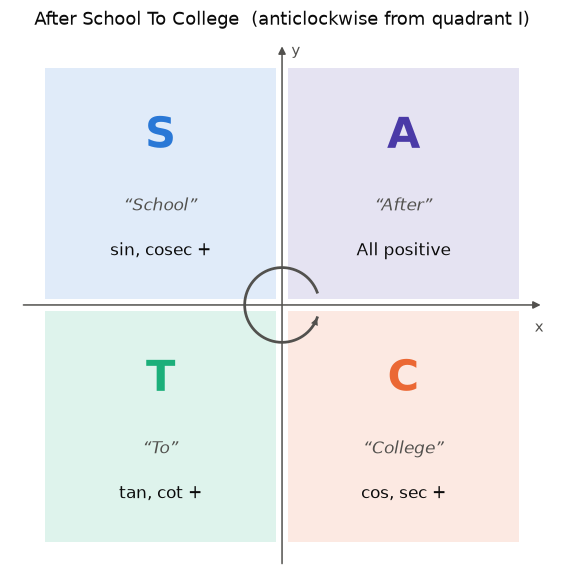

In [2]:
fig, ax = plt.subplots(figsize=(6.4, 6.4)); clean(ax, 1.45)
labels = {1: ("A", "After", "All positive"), 2: ("S", "School", "sin, cosec +"),
          3: ("T", "To", "tan, cot +"), 4: ("C", "College", "cos, sec +")}
colors = {1: VIOLET, 2: BLUE, 3: AQUA, 4: ORANGE}
corners = {1: (0, 0), 2: (-1.3, 0), 3: (-1.3, -1.3), 4: (0, -1.3)}
for q, (x0, y0) in corners.items():
    ax.add_patch(Rectangle((x0 + 0.03, y0 + 0.03), 1.24, 1.24, fc=colors[q], alpha=0.14, ec="none"))
    cx, cy = x0 + 0.65, y0 + 0.65
    letter, word, meaning = labels[q]
    ax.text(cx, cy + 0.25, letter, ha="center", va="center", fontsize=28, color=colors[q], fontweight="bold")
    ax.text(cx, cy - 0.12, f"“{word}”", ha="center", va="center", fontsize=11, color=INK2, style="italic")
    ax.text(cx, cy - 0.36, meaning, ha="center", va="center", fontsize=11, color=INK)
axes_cross(ax, 1.4)
sweep(ax, 20, 340, r0=0.2, color=INK2)
ax.set_title("After School To College  (anticlockwise from quadrant I)", fontsize=12)
plt.show()

---
## 2. Recap: $\sin x$ and $\cos x$

| Function | Domain | Range |
|---|---|---|
| $\sin x$ ("papa") | $\mathbb{R} = (-\infty, \infty)$ | $[-1, 1]$ |
| $\cos x$ ("mummy") | $\mathbb{R} = (-\infty, \infty)$ | $[-1, 1]$ |

From this lecture on, the lecturer works **mostly in radians**. Get comfortable with $\frac{\pi}{2}, \pi, \frac{3\pi}{2}, \dots$ instead of $90^\circ, 180^\circ, 270^\circ$.

Two facts drive the domains of the other four functions:

$$\cos x = 0 \iff x = \pm\frac{\pi}{2}, \pm\frac{3\pi}{2}, \pm\frac{5\pi}{2}, \dots = (2n+1)\frac{\pi}{2}, \quad n \in \mathbb{Z} \quad \text{(odd multiples of } \tfrac{\pi}{2})$$

$$\sin x = 0 \iff x = 0, \pm\pi, \pm 2\pi, \dots = n\pi, \quad n \in \mathbb{Z} \quad \text{(integer multiples of } \pi)$$

Here $(2n+1)$ is the standard way to write an **odd integer**.

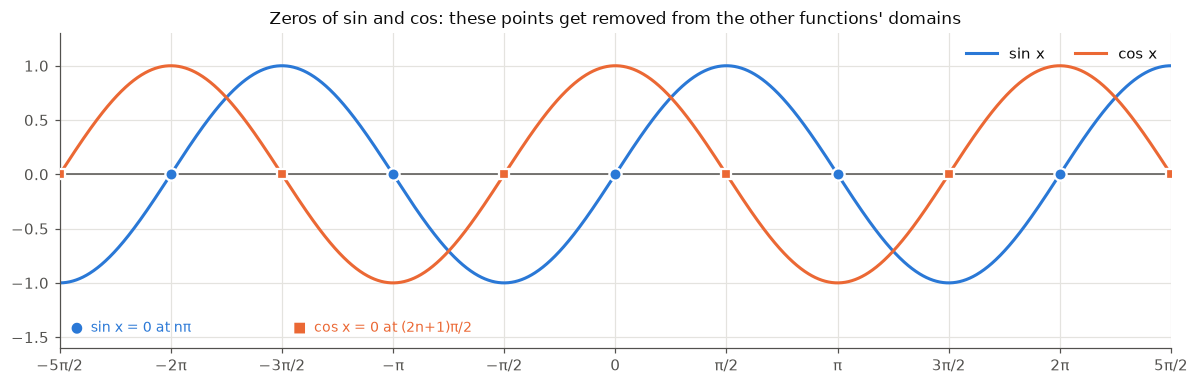

In [3]:
x = np.linspace(-2.5*np.pi, 2.5*np.pi, 2000)
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(x, np.sin(x), color=BLUE, lw=2, label="sin x")
ax.plot(x, np.cos(x), color=ORANGE, lw=2, label="cos x")
ax.axhline(0, color=INK2, lw=1)
zs = np.arange(-2, 3)*np.pi
zc = (2*np.arange(-3, 3) + 1)*np.pi/2
ax.plot(zs, 0*zs, "o", color=BLUE, ms=8, mec="white", mew=1.5, zorder=4)
ax.plot(zc, 0*zc, "s", color=ORANGE, ms=7, mec="white", mew=1.5, zorder=4)
ax.text(-2.45*np.pi, -1.45, "●  sin x = 0 at nπ", color=BLUE, fontsize=9)
ax.text(-1.45*np.pi, -1.45, "■  cos x = 0 at (2n+1)π/2", color=ORANGE, fontsize=9)
pi_ticks(ax, -2.5, 2.5); ax.set_xlim(x[0], x[-1]); ax.set_ylim(-1.6, 1.3)
ax.legend(frameon=False, ncol=2, loc="upper right")
ax.set_title("Zeros of sin and cos: these points get removed from the other functions' domains", fontsize=11)
plt.tight_layout(); plt.show()

---
## 3. $\tan x$ and $\cot x$

### 3.1 $\tan x = \dfrac{\sin x}{\cos x}$
**Domain.** A denominator can never be $0$. If $\cos x = 0$ then $\tan x$ is **not defined**. So we remove the odd multiples of $\frac{\pi}{2}$:
$$\boxed{\text{Domain of } \tan x = \mathbb{R} - \left\{(2n+1)\frac{\pi}{2} : n \in \mathbb{Z}\right\}}$$

**Range.** $\tan x = \dfrac{P}{B}$, and in a right triangle $P$ and $B$ can be **anything**, independently:
- $P = 10$, $B = 0.1$ gives $\tan = 100$ (very large)
- $P = 0.1$, $B = 10$ gives $\tan = 0.01$ (very small)
- and either sign is possible depending on the quadrant

$$\boxed{\text{Range of } \tan x = \mathbb{R} = (-\infty, \infty)}$$

### 3.2 $\cot x = \dfrac{\cos x}{\sin x}$
**Domain.** If $\sin x = 0$, that is $x = n\pi$, then $\cot x$ is not defined:
$$\boxed{\text{Domain of } \cot x = \mathbb{R} - \{n\pi : n \in \mathbb{Z}\}}$$

**Range.** $\cot x = \dfrac{B}{P}$. The lecturer's example is a triangle whose base runs "from Kashmir to Sri Lanka" with a tiny perpendicular. Then $B/P$ is huge. Flip the proportions and it is tiny:
$$\boxed{\text{Range of } \cot x = \mathbb{R} = (-\infty, \infty)}$$

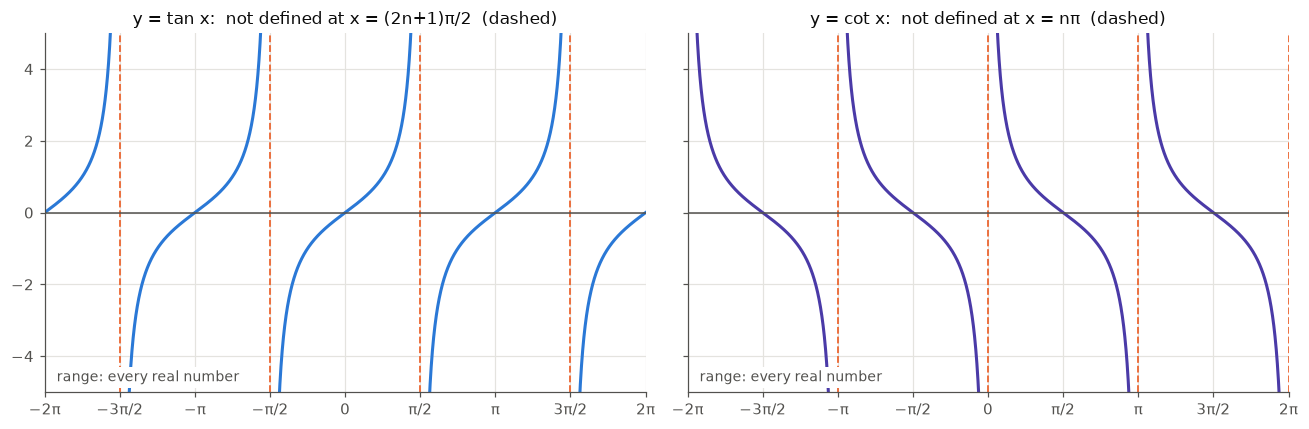

In [4]:
x = np.linspace(-2*np.pi + 0.001, 2*np.pi - 0.001, 6000)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, f, name, holes, col in [
        (axes[0], np.tan, "tan x", (2*np.arange(-2, 2) + 1)*np.pi/2, BLUE),
        (axes[1], lambda t: 1/np.tan(t), "cot x", np.arange(-2, 3)*np.pi, VIOLET)]:
    ax.plot(x, masked(f, x), color=col, lw=2)
    for h in holes:
        ax.axvline(h, color=ORANGE, lw=1.2, ls="--")
    ax.axhline(0, color=INK2, lw=1)
    pi_ticks(ax, -2, 2); ax.set_xlim(-2*np.pi, 2*np.pi); ax.set_ylim(-5, 5)
    excluded = "(2n+1)π/2" if name == "tan x" else "nπ"
    ax.set_title(f"y = {name}:  not defined at x = {excluded}  (dashed)", fontsize=11)
    ax.text(0.02, 0.03, "range: every real number", transform=ax.transAxes, color=INK2, fontsize=9,
            bbox=dict(fc="white", ec="none", pad=2))
plt.tight_layout(); plt.show()

---
## 4. $\sec x$ and $\csc x$

### 4.1 $\sec x = \dfrac{1}{\cos x}$
**Domain.** Same problem as $\tan$: $\cos x$ is in the denominator.
$$\boxed{\text{Domain of } \sec x = \mathbb{R} - \left\{(2n+1)\frac{\pi}{2} : n \in \mathbb{Z}\right\}}$$

**Range.** $\cos x \in [-1, 1]$, and $\cos x \neq 0$ here. Take reciprocals of numbers in that interval:
- A number in $(0, 1]$ has a reciprocal **$\ge 1$**. For example $\tfrac{1}{0.001} = 1000$.
- A number in $[-1, 0)$ has a reciprocal **$\le -1$**.

$$\boxed{\text{Range of } \sec x = (-\infty, -1] \cup [1, \infty)}$$

So $\sec x$ can **never** lie strictly between $-1$ and $1$. For example $\sec x = \tfrac12$ is impossible.

### 4.2 $\csc x = \dfrac{1}{\sin x}$
**Domain.** $\sin x$ is in the denominator, so remove $x = n\pi$:
$$\boxed{\text{Domain of } \csc x = \mathbb{R} - \{n\pi : n \in \mathbb{Z}\}}$$

**Range.** $\sin$ and $\cos$ have the **same range**, so their reciprocals do too:
$$\boxed{\text{Range of } \csc x = (-\infty, -1] \cup [1, \infty)}$$

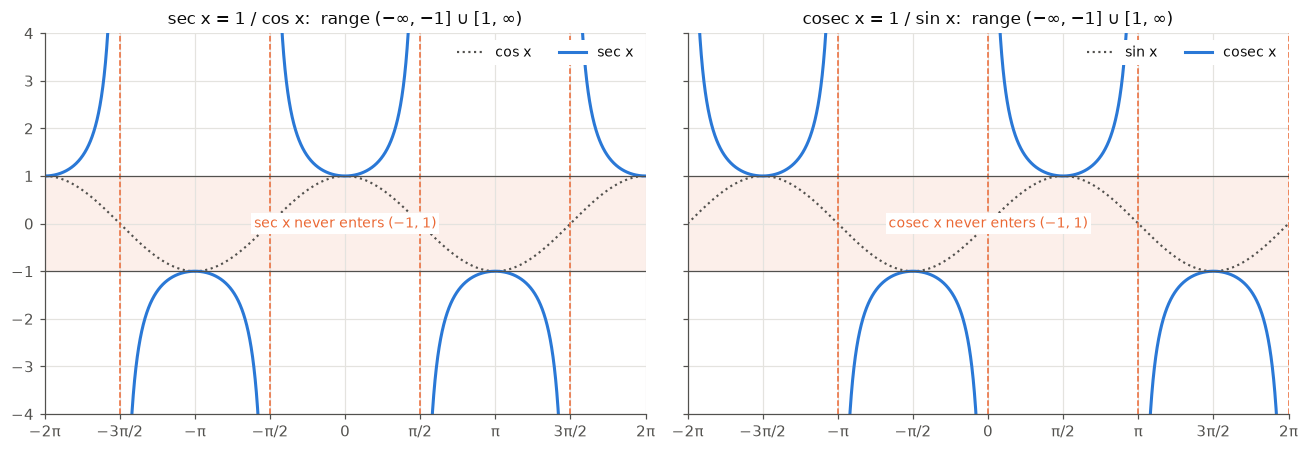

In [5]:
x = np.linspace(-2*np.pi + 0.001, 2*np.pi - 0.001, 6000)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, base, recip, bname, rname, holes in [
        (axes[0], np.cos, lambda t: 1/np.cos(t), "cos x", "sec x", (2*np.arange(-2, 2) + 1)*np.pi/2),
        (axes[1], np.sin, lambda t: 1/np.sin(t), "sin x", "cosec x", np.arange(-2, 3)*np.pi)]:
    ax.axhspan(-1, 1, color=NEG_BG, lw=0)
    ax.plot(x, base(x), color=INK2, lw=1.4, ls=":", label=bname)
    ax.plot(x, masked(recip, x), color=BLUE, lw=2, label=rname)
    for h in holes:
        ax.axvline(h, color=ORANGE, lw=1, ls="--")
    ax.axhline(1, color=INK2, lw=0.8); ax.axhline(-1, color=INK2, lw=0.8)
    pi_ticks(ax, -2, 2); ax.set_xlim(-2*np.pi, 2*np.pi); ax.set_ylim(-4, 4)
    ax.text(0.5, 0.5, f"{rname} never enters (−1, 1)", transform=ax.transAxes, ha="center", va="center",
            color=ORANGE, fontsize=9, bbox=dict(fc="white", ec="none", pad=2))
    ax.legend(frameon=True, framealpha=1, edgecolor="none", loc="upper right", ncol=2, fontsize=9)
    ax.set_title(f"{rname} = 1 / {bname}:  range (−∞, −1] ∪ [1, ∞)", fontsize=11)
plt.tight_layout(); plt.show()

### 4.3 Summary of all six functions

| Function | Domain | Range |
|---|---|---|
| $\sin x$ | $\mathbb{R}$ | $[-1, 1]$ |
| $\cos x$ | $\mathbb{R}$ | $[-1, 1]$ |
| $\tan x$ | $\mathbb{R} - \left\{(2n+1)\frac{\pi}{2}\right\}$ | $\mathbb{R}$ |
| $\cot x$ | $\mathbb{R} - \{n\pi\}$ | $\mathbb{R}$ |
| $\sec x$ | $\mathbb{R} - \left\{(2n+1)\frac{\pi}{2}\right\}$ | $(-\infty, -1] \cup [1, \infty)$ |
| $\csc x$ | $\mathbb{R} - \{n\pi\}$ | $(-\infty, -1] \cup [1, \infty)$ |

($n \in \mathbb{Z}$ throughout.)

**Pattern to remember:**
- Functions with $\cos$ in the denominator ($\tan$, $\sec$) lose the odd multiples of $\frac{\pi}{2}$.
- Functions with $\sin$ in the denominator ($\cot$, $\csc$) lose the multiples of $\pi$.
- Pairs share a range: $\sin$ and $\cos$; $\tan$ and $\cot$; $\sec$ and $\csc$.

Knowing a function's domain and range tells you its **behaviour**, which is why the lecturer insists on memorising them.

In [6]:
# Numerical sanity check: sample many x, drop the undefined points, look at the outputs
rng = np.random.default_rng(0)
xs = rng.uniform(-50, 50, 200_000)
funcs = {"sin": np.sin, "cos": np.cos, "tan": np.tan, "cot": lambda t: 1/np.tan(t),
         "sec": lambda t: 1/np.cos(t), "cosec": lambda t: 1/np.sin(t)}
print(f"{'f(x)':>6} | {'min |f|':>9} | {'max |f|':>12} | values inside (−1, 1)?")
print("-" * 58)
for name, f in funcs.items():
    y = f(xs)
    inside = np.mean(np.abs(y) < 1) * 100
    print(f"{name:>6} | {np.min(np.abs(y)):9.5f} | {np.max(np.abs(y)):12.2f} | {inside:5.1f}% of samples")

  f(x) |   min |f| |      max |f| | values inside (−1, 1)?
----------------------------------------------------------
   sin |   0.00001 |         1.00 | 100.0% of samples
   cos |   0.00000 |         1.00 | 100.0% of samples
   tan |   0.00001 |    466259.13 |  49.7% of samples
   cot |   0.00000 |    166575.35 |  50.3% of samples
   sec |   1.00000 |    466259.13 |   0.0% of samples
 cosec |   1.00000 |    166575.35 |   0.0% of samples


---
## 5. Solved Question: An Impossible Equation

> **Prove that** $\sin\theta = x^2 + \dfrac{1}{x^2}$ **is impossible for any real $x$** (with $x \neq 0$).

**First understand the question.** "Impossible" means no real value of $x$ gives a right-hand side that $\sin\theta$ can equal. The lecturer stresses that every question has two parts: **understanding it** and then **solving it**.

**Trick: add and subtract $2$** to complete a square on the right-hand side:
$$x^2 + \frac{1}{x^2} = \left(x^2 + \frac{1}{x^2} - 2\right) + 2 = \left(x - \frac{1}{x}\right)^2 + 2$$

since $\left(x - \frac1x\right)^2 = x^2 - 2 + \frac{1}{x^2}$.

**Compare the ranges of both sides:**
- **LHS:** $\sin\theta \le 1$ always (range of $\sin$).
- **RHS:** $2 + (\text{a square}) \ge 2$, because a square is never negative.

$$\underbrace{\sin\theta}_{\le\, 1} \;=\; \underbrace{\left(x - \tfrac1x\right)^2 + 2}_{\ge\, 2}$$

A value that is at most 1 can never equal a value that is at least 2, so **the equation has no real solution** $\blacksquare$

**Concept used:** the *range* of each side. If the two ranges do not overlap, the equation is impossible.

> The quantity "number + its reciprocal" ($x + \frac1x$, $x^2 + \frac{1}{x^2}$) appears often. For $x > 0$, $x + \frac1x \ge 2$, with the minimum $2$ at $x = 1$.

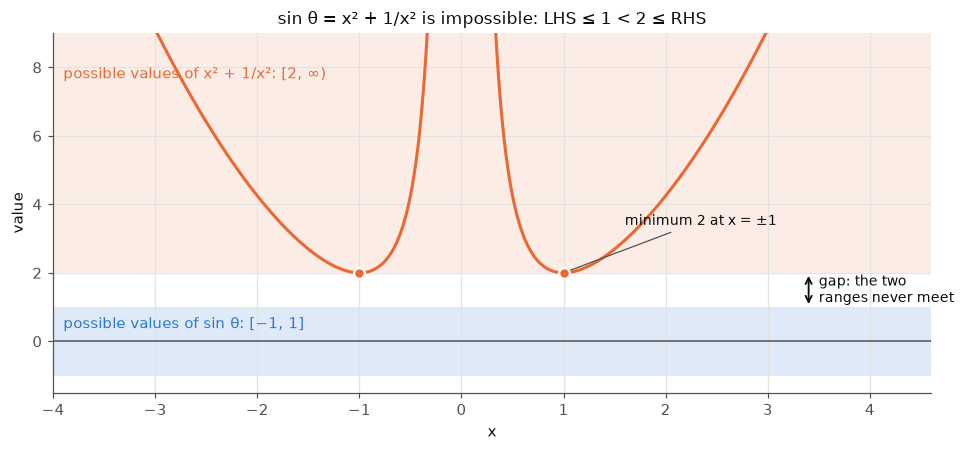

smallest RHS found numerically: 2.000000


In [7]:
xv = np.linspace(-4, 4, 4001); xv = xv[np.abs(xv) > 0.15]
rhs = xv**2 + 1/xv**2
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.axhspan(-1, 1, color=BLUE, alpha=0.15, lw=0)
ax.axhspan(2, 9, color=ORANGE, alpha=0.12, lw=0)
for side in (xv < 0, xv > 0):
    ax.plot(xv[side], rhs[side], color=ORANGE, lw=2)
ax.plot([-1, 1], [2, 2], "o", color=ORANGE, ms=7, mec="white", mew=1.5, zorder=4)
ax.annotate("minimum 2 at x = ±1", (1, 2), xytext=(1.6, 3.4), fontsize=9,
            arrowprops=dict(arrowstyle="-", color=INK2, lw=0.8))
ax.text(-3.9, 0.5, "possible values of sin θ: [−1, 1]", color=BLUE, va="center", fontsize=10)
ax.text(-3.9, 7.8, "possible values of x² + 1/x²: [2, ∞)", color=ORANGE, va="center", fontsize=10)
ax.annotate("", xy=(3.4, 2), xytext=(3.4, 1), arrowprops=dict(arrowstyle="<->", color=INK, lw=1.2))
ax.text(3.5, 1.5, "gap: the two\nranges never meet", va="center", fontsize=9)
ax.axhline(0, color=INK2, lw=1)
ax.set_xlim(-4, 4.6); ax.set_ylim(-1.5, 9); ax.set_xlabel("x"); ax.set_ylabel("value")
ax.set_title("sin θ = x² + 1/x² is impossible: LHS ≤ 1 < 2 ≤ RHS", fontsize=11)
plt.tight_layout(); plt.show()
print(f"smallest RHS found numerically: {rhs.min():.6f}")

---
## 6. The Trigonometric Table (in radians)

The most used ("loving") angles are $0, \frac{\pi}{6}, \frac{\pi}{4}, \frac{\pi}{3}, \frac{\pi}{2}$ (that is, $0^\circ, 30^\circ, 45^\circ, 60^\circ, 90^\circ$). These values must be memorised so you can recall them **instantly** and without thinking. They will be used throughout Class 11 and 12.

| $\theta$ | $0$ | $\frac{\pi}{6}$ | $\frac{\pi}{4}$ | $\frac{\pi}{3}$ | $\frac{\pi}{2}$ |
|---|---|---|---|---|---|
| $\sin\theta$ | $0$ | $\frac12$ | $\frac{1}{\sqrt2}$ | $\frac{\sqrt3}{2}$ | $1$ |
| $\cos\theta$ | $1$ | $\frac{\sqrt3}{2}$ | $\frac{1}{\sqrt2}$ | $\frac12$ | $0$ |
| $\tan\theta$ | $0$ | $\frac{1}{\sqrt3}$ | $1$ | $\sqrt3$ | **not defined** |
| $\cot\theta$ | **not defined** | $\sqrt3$ | $1$ | $\frac{1}{\sqrt3}$ | $0$ |
| $\sec\theta$ | $1$ | $\frac{2}{\sqrt3}$ | $\sqrt2$ | $2$ | **not defined** |
| $\csc\theta$ | **not defined** | $2$ | $\sqrt2$ | $\frac{2}{\sqrt3}$ | $1$ |

**Memory aids:**
- The $\cos$ row is the $\sin$ row **reversed**.
- $\tan = \sin/\cos$, and each reciprocal row is $1 / (\text{its partner row})$.
- A common trick (not from the lecture): $\sin\theta = \dfrac{\sqrt{0}}{2}, \dfrac{\sqrt{1}}{2}, \dfrac{\sqrt{2}}{2}, \dfrac{\sqrt{3}}{2}, \dfrac{\sqrt{4}}{2}$.

### "Not defined" vs. "infinity"
Some books write $\tan\frac{\pi}{2} = \infty$. **That is wrong.** $\tan\frac{\pi}{2}$ is **not defined**:
- **Infinity** means something that *exists* and is enormous, like an ocean.
- **Not defined** means something that *does not exist at all*.

$\tan\frac{\pi}{2} = \dfrac{1}{0}$ is not defined, and so are $\cot 0$, $\sec\frac{\pi}{2}$ and $\csc 0$.

Practise by quizzing yourself: *"$\tan\frac{\pi}{4}$? $\cos\frac{\pi}{3}$? $\sec\frac{\pi}{2}$?"* until the answers come immediately.

In [8]:
angles = [0, np.pi/6, np.pi/4, np.pi/3, np.pi/2]
names = ["0", "π/6", "π/4", "π/3", "π/2"]
f6 = {"sin": np.sin, "cos": np.cos, "tan": np.tan, "cot": lambda t: np.cos(t)/np.sin(t),
      "sec": lambda t: 1/np.cos(t), "cosec": lambda t: 1/np.sin(t)}

def cell(f, t):
    with np.errstate(divide="ignore"):
        v = f(t)
    return "not defined" if (not np.isfinite(v) or abs(v) > 1e12) else f"{v:.4f}"

print(f"{'':>6} | " + " | ".join(f"{n:>11}" for n in names))
print("-" * 76)
for k, f in f6.items():
    print(f"{k:>6} | " + " | ".join(f"{cell(f, t):>11}" for t in angles))

       |           0 |         π/6 |         π/4 |         π/3 |         π/2
----------------------------------------------------------------------------
   sin |      0.0000 |      0.5000 |      0.7071 |      0.8660 |      1.0000
   cos |      1.0000 |      0.8660 |      0.7071 |      0.5000 |      0.0000
   tan |      0.0000 |      0.5774 |      1.0000 |      1.7321 | not defined
   cot | not defined |      1.7321 |      1.0000 |      0.5774 |      0.0000
   sec |      1.0000 |      1.1547 |      1.4142 |      2.0000 | not defined
 cosec | not defined |      2.0000 |      1.4142 |      1.1547 |      1.0000


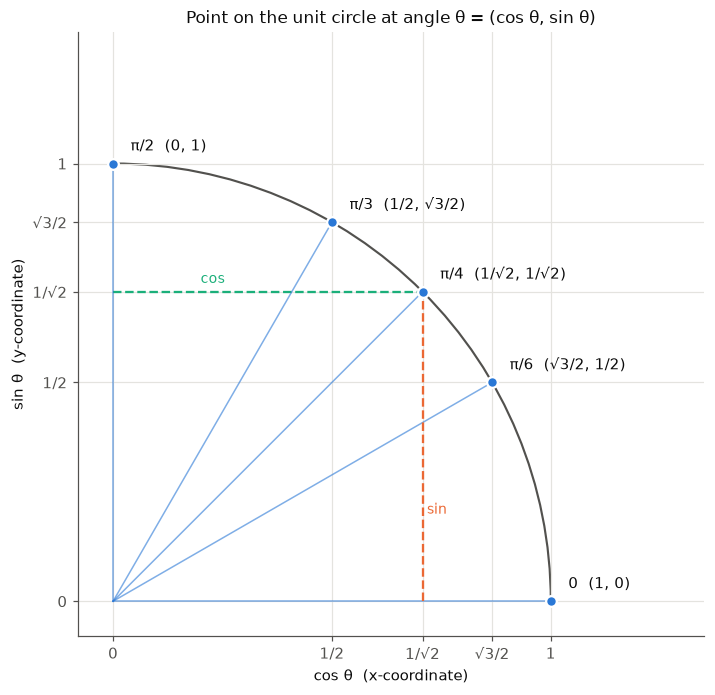

In [9]:
# The first-quadrant unit circle: each standard angle's point is (cos θ, sin θ)
fig, ax = plt.subplots(figsize=(6.6, 6.6))
ax.set_aspect("equal"); ax.set_xlim(-0.08, 1.35); ax.set_ylim(-0.08, 1.3)
ax.add_patch(Arc((0, 0), 2, 2, theta1=0, theta2=90, color=INK2, lw=1.4))
pretty = {0: ("0", "(1, 0)"), 30: ("π/6", "(√3/2, 1/2)"), 45: ("π/4", "(1/√2, 1/√2)"),
          60: ("π/3", "(1/2, √3/2)"), 90: ("π/2", "(0, 1)")}
for d, (lab, coord) in pretty.items():
    t = np.deg2rad(d); c, s = np.cos(t), np.sin(t)
    ax.plot([0, c], [0, s], color=BLUE, lw=1, alpha=0.6)
    ax.plot(c, s, "o", color=BLUE, ms=7, mec="white", mew=1.5, zorder=4)
    if d == 45:
        ax.plot([c, c], [0, s], color=ORANGE, lw=1.5, ls="--"); ax.plot([0, c], [s, s], color=AQUA, lw=1.5, ls="--")
    ax.text(c + 0.04, s + 0.03, f"{lab}  {coord}", fontsize=10, ha="left" if d < 90 else "left")
ax.text(np.cos(np.pi/4) + 0.01, 0.2, "sin", color=ORANGE, fontsize=9)
ax.text(0.2, np.sin(np.pi/4) + 0.02, "cos", color=AQUA, fontsize=9)
ax.set_xlabel("cos θ  (x-coordinate)"); ax.set_ylabel("sin θ  (y-coordinate)")
ax.set_xticks([0, 0.5, 1/np.sqrt(2), np.sqrt(3)/2, 1], ["0", "1/2", "1/√2", "√3/2", "1"])
ax.set_yticks([0, 0.5, 1/np.sqrt(2), np.sqrt(3)/2, 1], ["0", "1/2", "1/√2", "√3/2", "1"])
ax.set_title("Point on the unit circle at angle θ = (cos θ, sin θ)", fontsize=11)
plt.tight_layout(); plt.show()

---
## 7. Trig Ratios of Angles of Any Magnitude

$\sin, \cos, \dots$ can be evaluated for **any** angle: $\frac{7\pi}{3}$, $1410^\circ$, $5000^\circ$, even a million degrees. You do **not** need a bigger table. You need **this table + two rules**. This lecture introduces the idea, and the next lecture covers it in detail.

### 7.1 Complementary angles (Class 10)
$$\sin\left(\tfrac{\pi}{2} - \theta\right) = \cos\theta, \qquad \cos\left(\tfrac{\pi}{2} - \theta\right) = \sin\theta$$
$$\tan\left(\tfrac{\pi}{2} - \theta\right) = \cot\theta, \qquad \cot\left(\tfrac{\pi}{2} - \theta\right) = \tan\theta$$
$$\sec\left(\tfrac{\pi}{2} - \theta\right) = \csc\theta, \qquad \csc\left(\tfrac{\pi}{2} - \theta\right) = \sec\theta$$

**Why:** in a right triangle with angle $\theta$, the third angle is $\frac{\pi}{2} - \theta$. The side **opposite** $\theta$ is **adjacent** to $\frac{\pi}{2} - \theta$, so $P$ and $B$ swap roles while $H$ stays the same.

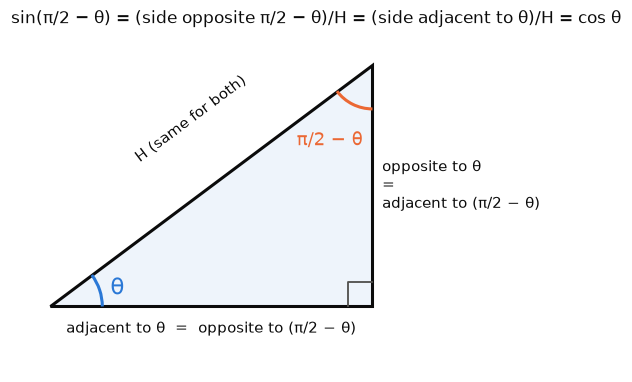

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.2)); ax.set_aspect("equal"); ax.axis("off")
A, B, C = np.array([0, 0]), np.array([4, 0]), np.array([4, 3])
ax.add_patch(Polygon([A, B, C], closed=True, fc="#2a78d614", ec=INK, lw=2))
ax.plot([3.7, 3.7, 4], [0, 0.3, 0.3], color=INK2, lw=1.2)
ax.add_patch(Arc(A, 1.3, 1.3, theta1=0, theta2=36.87, color=BLUE, lw=2))
ax.text(0.75, 0.15, "θ", color=BLUE, fontsize=15)
ax.add_patch(Arc(C, 1.1, 1.1, theta1=216.87, theta2=270, color=ORANGE, lw=2))
ax.text(3.88, 2.0, "π/2 − θ", color=ORANGE, fontsize=12, ha="right")
ax.text(2, -0.18, "adjacent to θ  =  opposite to (π/2 − θ)", ha="center", va="top", fontsize=10)
ax.text(4.12, 1.5, "opposite to θ\n=\nadjacent to (π/2 − θ)", ha="left", va="center", fontsize=10)
ax.text(1.75, 1.75, "H (same for both)", ha="center", va="bottom", fontsize=10, rotation=36.87)
ax.set_xlim(-0.4, 7); ax.set_ylim(-0.8, 3.4)
ax.set_title("sin(π/2 − θ) = (side opposite π/2 − θ)/H = (side adjacent to θ)/H = cos θ", fontsize=11)
plt.show()

### 7.2 Allied angles: the two rules
Other relations such as $\pi - \theta$, $\pi + \theta$, $\frac{3\pi}{2} - \theta$ and $2\pi - \theta$ need not be memorised individually. For an expression like $f(\text{axis angle} \pm \theta)$, where $\theta$ is treated as **acute**:

**Rule 1: the sign.** Find which **quadrant** the angle $(\text{axis angle} \pm \theta)$ lies in. Use the sign scheme (After School To College) to decide whether $f$ is $+$ or $-$ there. Use the sign of the **original** function $f$.

**Rule 2: does the function change?**
- If the axis angle lies on the **x-axis** ($0, \pi, 2\pi, 3\pi, \dots$, i.e. $n\pi$), the function **stays the same**: $\sin \to \sin$, $\cos \to \cos$, and so on.
- If the axis angle lies on the **y-axis** ($\frac{\pi}{2}, \frac{3\pi}{2}, \frac{5\pi}{2}, \dots$, i.e. odd multiples of $\frac{\pi}{2}$), the function **changes to its co-function**:

$$\sin \leftrightarrow \cos, \qquad \tan \leftrightarrow \cot, \qquad \sec \leftrightarrow \csc$$

**Example: $\sin(\pi - \theta)$.**
1. $\pi - \theta$: rotate to $\pi$, then come back by $\theta$. That lands in **quadrant II**, where $\sin$ is **positive**.
2. $\pi$ is on the **x-axis**, so $\sin$ stays $\sin$.

$$\sin(\pi - \theta) = +\sin\theta$$

Similarly, in quadrant II only $\sin$ and $\csc$ are positive:
$$\cos(\pi-\theta) = -\cos\theta,\quad \tan(\pi-\theta) = -\tan\theta,\quad \cot(\pi-\theta) = -\cot\theta,\quad \sec(\pi-\theta) = -\sec\theta,\quad \csc(\pi-\theta) = \csc\theta$$

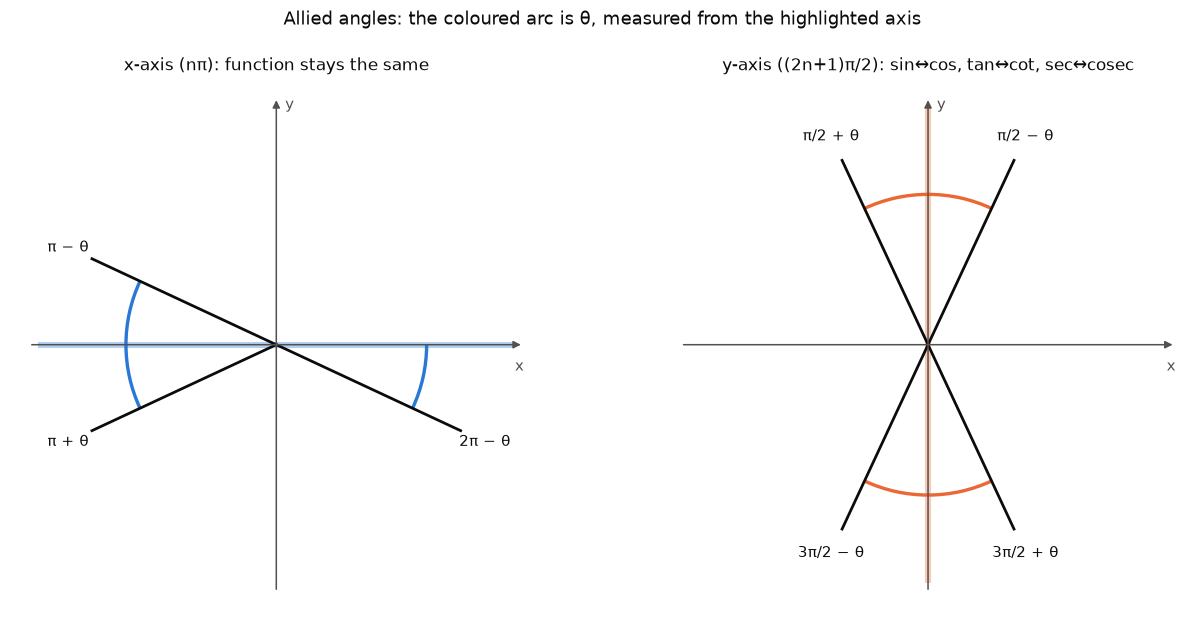

In [11]:
th = 25                                               # a representative acute θ (degrees)
fig, axes = plt.subplots(1, 2, figsize=(12, 5.6))
cases = [
    (axes[0], [(180, -1, "π − θ"), (180, 1, "π + θ"), (360, -1, "2π − θ")], "x-axis (nπ): function stays the same", BLUE),
    (axes[1], [(90, 1, "π/2 + θ"), (90, -1, "π/2 − θ"), (270, -1, "3π/2 − θ"), (270, 1, "3π/2 + θ")],
     "y-axis ((2n+1)π/2): sin↔cos, tan↔cot, sec↔cosec", ORANGE),
]
for ax, items, title, col in cases:
    clean(ax, 1.5)
    axes_cross(ax, 1.4)
    axis_line = [(-1.35, 0), (1.35, 0)] if col == BLUE else [(0, -1.35), (0, 1.35)]
    ax.plot(*zip(*axis_line), color=col, lw=4, alpha=0.35, solid_capstyle="butt")
    for base, sgn, lab in items:
        a = base + sgn*th; r = np.deg2rad(a)
        ax.plot([0, 1.15*np.cos(r)], [0, 1.15*np.sin(r)], color=INK, lw=1.8)
        ax.add_patch(Arc((0, 0), 1.7, 1.7, theta1=min(base, a), theta2=max(base, a), color=col, lw=2.2))
        ax.text(1.3*np.cos(r), 1.3*np.sin(r), lab, ha="center", va="center", fontsize=10,
                bbox=dict(fc="white", ec="none", pad=1))
    ax.set_title(title, fontsize=11)
fig.suptitle("Allied angles: the coloured arc is θ, measured from the highlighted axis", fontsize=12, y=1.0)
plt.tight_layout(); plt.show()

### 7.3 Check the rules numerically
For every allied angle, the next cell applies the two rules **symbolically** and compares the result with the actual value at a random $\theta$.

In [12]:
F = {"sin": np.sin, "cos": np.cos, "tan": np.tan, "cot": lambda t: 1/np.tan(t),
     "sec": lambda t: 1/np.cos(t), "cosec": lambda t: 1/np.sin(t)}
CO = {"sin": "cos", "cos": "sin", "tan": "cot", "cot": "tan", "sec": "cosec", "cosec": "sec"}
POSITIVE_IN = {1: set(F), 2: {"sin", "cosec"}, 3: {"tan", "cot"}, 4: {"cos", "sec"}}

def apply_rules(fname, k, sign):
    # f(kπ/2 + sign·θ) for acute θ  →  (±, new function)
    quadrant = int(((k*90 + sign*30) % 360) // 90) + 1          # test with θ = 30° to locate the quadrant
    s = "+" if fname in POSITIVE_IN[quadrant] else "−"           # Rule 1: sign of the ORIGINAL function
    g = fname if k % 2 == 0 else CO[fname]                        # Rule 2: x-axis keeps, y-axis swaps
    return s, g, quadrant

theta = 0.37                                                     # any acute angle (radians)
labels = {1: "π/2", 2: "π", 3: "3π/2", 4: "2π"}
ok = 0; total = 0
print(f"{'expression':>16}  {'Q':>3}   {'rule says':<10} check")
for k in [1, 2, 3, 4]:
    for sign in (-1, 1):
        for fname in ["sin", "cos", "tan"]:
            s, g, q = apply_rules(fname, k, sign)
            actual = F[fname](k*np.pi/2 + sign*theta)
            predicted = (1 if s == "+" else -1) * F[g](theta)
            good = np.isclose(actual, predicted); ok += good; total += 1
            expr = f"{fname}({labels[k]} {'+' if sign > 0 else '−'} θ)"
            print(f"{expr:>16}  {['I','II','III','IV'][q-1]:>3}   {s}{g} θ{'':<4} {'✓' if good else '✗'}")
print(f"\n{ok}/{total} identities confirmed")

      expression    Q   rule says  check
    sin(π/2 − θ)    I   +cos θ     ✓
    cos(π/2 − θ)    I   +sin θ     ✓
    tan(π/2 − θ)    I   +cot θ     ✓
    sin(π/2 + θ)   II   +cos θ     ✓
    cos(π/2 + θ)   II   −sin θ     ✓
    tan(π/2 + θ)   II   −cot θ     ✓
      sin(π − θ)   II   +sin θ     ✓
      cos(π − θ)   II   −cos θ     ✓
      tan(π − θ)   II   −tan θ     ✓
      sin(π + θ)  III   −sin θ     ✓
      cos(π + θ)  III   −cos θ     ✓
      tan(π + θ)  III   +tan θ     ✓
   sin(3π/2 − θ)  III   −cos θ     ✓
   cos(3π/2 − θ)  III   −sin θ     ✓
   tan(3π/2 − θ)  III   +cot θ     ✓
   sin(3π/2 + θ)   IV   −cos θ     ✓
   cos(3π/2 + θ)   IV   +sin θ     ✓
   tan(3π/2 + θ)   IV   −cot θ     ✓
     sin(2π − θ)   IV   −sin θ     ✓
     cos(2π − θ)   IV   +cos θ     ✓
     tan(2π − θ)   IV   −tan θ     ✓
     sin(2π + θ)    I   +sin θ     ✓
     cos(2π + θ)    I   +cos θ     ✓
     tan(2π + θ)    I   +tan θ     ✓

24/24 identities confirmed


---
## 8. Summary

- **Sign scheme:** After School To College, i.e. **A**ll (I), **S**in/cosec (II), **T**an/cot (III), **C**os/sec (IV).
- **Domains:** $\cos$ in the denominator removes $(2n+1)\frac{\pi}{2}$; $\sin$ in the denominator removes $n\pi$.
- **Ranges:** $\sin, \cos \in [-1, 1]$; $\tan, \cot \in \mathbb{R}$; $\sec, \csc \in (-\infty, -1] \cup [1, \infty)$.
- **Range trick for equations:** if the ranges of LHS and RHS do not overlap, there is no solution. Example: $\sin\theta = x^2 + 1/x^2$.
- **Table:** memorise all six functions at $0, \frac{\pi}{6}, \frac{\pi}{4}, \frac{\pi}{3}, \frac{\pi}{2}$. Write *not defined*, never $\infty$.
- **Any magnitude:** table + two rules. Rule 1 takes the sign from the quadrant. Rule 2 keeps the function on the x-axis and swaps it on the y-axis.

---
## 9. Homework (from the lecture)
> Using the two rules, find:
> 1. $\sin(\pi - \theta)$
> 2. $\cos\left(\frac{\pi}{2} + \theta\right)$

<details>
<summary>Answers (open after attempting)</summary>

1. $\pi - \theta$ is in quadrant II, where $\sin$ is $+$. $\pi$ is on the x-axis, so the function is unchanged. **$\sin(\pi - \theta) = \sin\theta$**
2. $\frac{\pi}{2} + \theta$ is in quadrant II, where $\cos$ is $-$. $\frac{\pi}{2}$ is on the y-axis, so $\cos$ becomes $\sin$. **$\cos\left(\frac{\pi}{2} + \theta\right) = -\sin\theta$**
</details>

### Extra practice
3. Write the domain and range of all six functions from memory.
4. Is $\sec x = 0.7$ possible? Is $\tan x = 1000$? Is $\csc x = -1$?
5. Show that $\cos\theta = x + \dfrac{1}{x}$ has no solution for any $x > 0$. (Hint: compare ranges, as in Section 5.)

In [13]:
# Check homework answers numerically
t = 0.6
print(f"sin(π − θ)   = {np.sin(np.pi - t):.6f}   sin θ  = {np.sin(t):.6f}")
print(f"cos(π/2 + θ) = {np.cos(np.pi/2 + t):.6f}  −sin θ = {-np.sin(t):.6f}")

sin(π − θ)   = 0.564642   sin θ  = 0.564642
cos(π/2 + θ) = -0.564642  −sin θ = -0.564642
